#### Próximas tarefas:
- importar meu inventário e mesclar com o do fábio (organizar colunas - tarefa minha, pode seguir sem isso e dps eu arrumo)
- Ver se tem que somar NMVOC e CH4 --> COV (n tenho ctz)
- Robinho tá fzndo o de SOx

#### Bibliotecas e caminhos

In [100]:
import pandas as pd
import numpy as np
import geopandas as gpd
import xarray as xr
import glob, os
import pyproj
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from shapely.geometry import box

caminho_inv_fab = r'C:\Users\glima\OneDrive\Documentos\Mestrado_GitHub\007.2026 - AnaliseInvCMAQ\inputs\inv_fabio\emission_total_light.csv'
caminho_inv_gab = r'C:\Users\glima\OneDrive\Documentos\Mestrado_GitHub\007.2026 - AnaliseInvCMAQ\inputs\inv_gab\inventarioEmissoesIndustriaisIndustriaAlimenticiaBR_V3.csv'
caminho_br = r'C:\Users\glima\OneDrive\Documentos\Mestrado_GitHub\input_base\BR_UF_2025.shp'
caminho_cmaq = r'C:\Users\glima\OneDrive\Documentos\Mestrado_GitHub\007.2026 - AnaliseInvCMAQ\inputs\cmaq'

### Tratamento do inventário

In [24]:
inv_fab = pd.read_csv(caminho_inv_fab)
inv_gab = pd.read_csv(caminho_inv_gab)

C:\Users\glima\AppData\Local\Temp\ipykernel_42660\3447262504.py:1: DtypeWarning: Columns (0: SNAP, 1: Technology, 2: Abatement, 3: Region) have mixed types. Specify dtype option on import or set low_memory=False.
  inv_fab = pd.read_csv(caminho_inv_fab)


In [25]:
print(inv_fab.columns)

# NOx vou comparar com NO + NO2
# SOx vou comparar com SO2 --> Robinho ainda tá fazendo
# Os outros é comparação direta
poluentes_fab = ['CO','PM25','PM10','SOx','NOx','NMVOC','CH4'] 
chaves = ['CPF_CNPJ', 'NOME_PESSOA', 'Latitude', 'Longitude', 'ANO',
       'NM_MUN', 'SIGLA_UF', 'NFR', 'SETOR', 'SNAP', 'TIER', 'Technology',
       'Abatement', 'Fuel', 'Region']

Index(['CPF_CNPJ', 'NOME_PESSOA', 'Latitude', 'Longitude', 'ANO', 'CD_MUN',
       'NM_MUN', 'SIGLA_UF', 'NFR', 'SETOR', 'SNAP', 'TIER', 'Technology',
       'Abatement', 'Fuel', 'Region', 'NOx', 'TSP', 'PM10', 'PM25', 'BC',
       'SOx', 'CO', 'NMVOC', 'NH3', 'CH4', 'Pb', 'Cd', 'Hg', 'As', 'Cr', 'Cu',
       'Ni', 'Se', 'Zn', 'PCB', 'PCDDF', 'HCB', 'Benzopyrene',
       'Benzobfluoranthene', 'Benzokfluoranthene', 'Indenopyrene'],
      dtype='str')


In [29]:
print(inv_gab.columns)

estado_sigla = {
    'ACRE': 'AC', 'ALAGOAS': 'AL', 'AMAPA': 'AP', 'AMAZONAS': 'AM',
    'BAHIA': 'BA', 'CEARA': 'CE', 'DISTRITO FEDERAL': 'DF', 'ESPIRITO SANTO': 'ES',
    'GOIAS': 'GO', 'MARANHAO': 'MA', 'MATO GROSSO': 'MT', 'MATO GROSSO DO SUL': 'MS',
    'MINAS GERAIS': 'MG', 'PARA': 'PA', 'PARAIBA': 'PB', 'PARANA': 'PR',
    'PERNAMBUCO': 'PE', 'PIAUI': 'PI', 'RIO DE JANEIRO': 'RJ', 'RIO GRANDE DO NORTE': 'RN',
    'RIO GRANDE DO SUL': 'RS', 'RONDONIA': 'RO', 'RORAIMA': 'RR', 'SANTA CATARINA': 'SC',
    'SAO PAULO': 'SP', 'SERGIPE': 'SE', 'TOCANTINS': 'TO'
}

inv_gab['SIGLA_UF'] = inv_gab['ESTADO'].map(estado_sigla)
inv_gab['SNAP'] = ''

inv_gab.rename(columns={'Emissão NMCOV (ton)':'NMVOC',
                        'mv.nom_pessoa':'NOME_PESSOA',
                        'CNPJ':'CPF_CNPJ',
                        'LATITUDE':'Latitude',
                        'LONGITUDE':'Longitude',
                        'num_ano':'ANO',
                        'mv.nom_municipio':'NM_MUN',
                        'Sector':'SETOR',
                        'Type':'TIER',
                        }, inplace=True)

poluentes_gab = ['NMVOC'] 



Index(['CPF_CNPJ', 'MUNICIPIO', 'Latitude', 'Longitude', 'ESTADO',
       'SITUACAO CADASTRAL', 'CODIGO DA CATEGORIA', 'CODIGO DA ATIVIDADE',
       'ANO_INICIO', 'ANO_FIM', 'mv.num_cpf_cnpj', 'mv.nom_pessoa', 'NM_MUN',
       'ANO', 'cod_produto', 'unidade_medida', 'sig_unidmed', 'nom_produto',
       'qtd_produzida', 'qtd_instalada', 'informacao_sigilosa', 'tipo_sigilo',
       'lei_sigilo', 'info_sigilo', '_merge', 'status_v01', 'PRODLIST', 'NFR',
       'Table', 'SETOR', 'TIER', 'Technology', 'Fuel', 'Abatement', 'Region',
       'Pollutant', 'Value', 'Unit', 'CI_lower', 'CI_upper', 'Reference',
       'status_v02', 'contagem_total_grupo', 'status_v03', 'sig_unidmed_novo',
       'qtd_convertida_prev', 'categoria', 'q90_setor_prev', 'status_q90_prev',
       'status_serie', 'status_correcaoManualUnidade', 'fatorConversao',
       'qtd_convertida', 'mediana_serie', 'razao_vs_mediana', 'q95_categoria',
       'status_v04', 'status_v05', 'fator_escala', 'Unnamed: 59',
       'prodtonh

In [ ]:
colunas_fab = chaves + poluentes_fab
colunas_gab = chaves + poluentes_gab

inv = pd.concat([
    inv_fab[colunas_fab],
    inv_gab[colunas_gab]
], ignore_index=True)

inv


In [34]:
#Transformando em GeoDataFrame para análises espaciais
inv_gdf = gpd.GeoDataFrame(
    inv[colunas_fab],  # Usando as colunas do inventário do Fabio, que tem todos os poluentes
    geometry = gpd.points_from_xy(inv['Longitude'], inv['Latitude']),
    crs = 'EPSG:4326'
)

<Axes: >

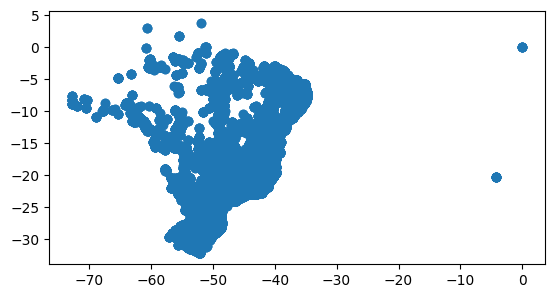

In [35]:
#Visualização das indústrias do inventário
inv_gdf.plot()

In [66]:
# Inventário contem pontos meio fora, vou fazer um buffer no limite do Brasil para filtrar tais pontos
brasil = gpd.read_file(caminho_br)
limite_brasil_buffer = brasil.union_all().buffer(0.1)

#filtrando pontos dentro do buffer (retirando pontos claramente errados)
mask = inv_gdf.intersects(limite_brasil_buffer)
fora = inv_gdf.loc[~mask]
inv_gdf_br = inv_gdf.loc[mask].reset_index(drop=True)

<Axes: >

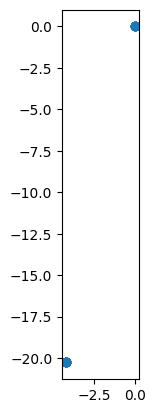

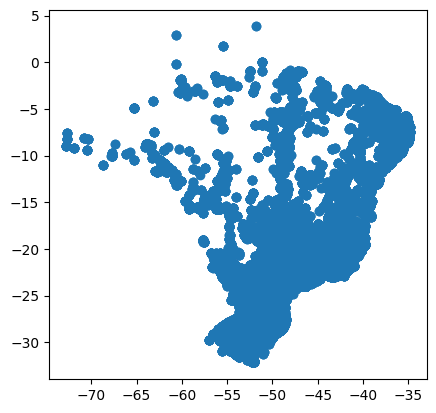

In [67]:
#visualização dos resultados do filtro
fora.plot()
inv_gdf_br.plot()

#### Trabalhando com os dados do CMAQ

#### Importação dos datasets

In [68]:
dataset = {}

for arquivo in glob.glob(os.path.join(caminho_cmaq, '*.nc')):
    nome = os.path.basename(arquivo)          # ex: BRAIN_SURFACE_NO2_2023...
    poluente = nome.split('_')[2]             # pega "NO", "NO2", "CO"...
    dataset[poluente] = xr.open_dataset(arquivo)

print(dataset.keys())

dict_keys(['CO', 'NO2', 'NO', 'O3', 'PM10', 'PM25'])


#### Verificando as unidades
A EPA analisa todos em µg/m³, com excessão do CO (que é em ppm) 

In [69]:
for poluente, ds in dataset.items():
    for var in ds.data_vars:
        unidade = ds[var].attrs.get('units', 'SEM ATRIBUTO units')
        print(f'{poluente:6} | var={var:12} | units = {unidade}')


CO     | var=CO           | units = ppm
NO2    | var=NO2          | units = ppm
NO     | var=NO           | units = ppm
O3     | var=O3           | units = ppm
PM10   | var=PM10         | units = $μg.m^{-3}$
PM25   | var=PM25         | units = $μg.m^{-3}$


#### Criando colunas com as unidades corrigidas

In [70]:
fator = {
    'NO2': 46.01 * 1000 / 24.45,   # ≈ 1881.8
    'O3':  48.00 * 1000 / 24.45,   # ≈ 1963.2
}

dataset['NO2']['NO2_ug'] = dataset['NO2']['NO2'] * fator['NO2']
dataset['NO2']['NO2_ug'].attrs['units'] = 'ug/m3'

dataset['O3']['O3_ug'] = dataset['O3']['O3'] * fator['O3']
dataset['O3']['O3_ug'].attrs['units'] = 'ug/m3'


#### Ajustando a unidade de tempo no dataset

In [105]:
print(dataset['NO2'].coords)
print(dataset['NO2']['TSTEP'].values[:5])

print(dataset['NO2'].data_vars)   # existe uma variável TFLAG?

print('SDATE:', dataset['NO2'].attrs.get('SDATE'))   # data inicial (AAAADDD)
print('STIME:', dataset['NO2'].attrs.get('STIME'))   # hora inicial (HHMMSS)
print('TSTEP:', dataset['NO2'].attrs.get('TSTEP'))   # passo de tempo (HHMMSS)

print('\nA data certa é a do nome do arquivo. Robinho vai arrumar essa data aqui (SDATE)')

inicio = '2023-08-26 00:00'        # início real (do nome do arquivo)
corte_spinup = '2023-09-01'        # descarta 26–31/08 (spin-up do modelo)

for poluente, ds in dataset.items():
    n = ds.sizes['TSTEP']
    tempo = pd.date_range(start=inicio, periods=n, freq='h')
    ds = ds.assign_coords(TSTEP=tempo)                       # cola a data
    dataset[poluente] = ds.sel(TSTEP=slice(corte_spinup, None))  # mantém só a partir de 01/09

# confirma o novo tamanho da série
print('TSTEP depois do corte:', dataset['NO2'].sizes['TSTEP'])          # ~744 (31 dias)
print('intervalo:', dataset['NO2']['TSTEP'].values[[0, -1]])            # 01/09 00h -> 01/10 23h


Coordinates:
  * TSTEP    (TSTEP) datetime64[us] 7kB 2023-08-26 ... 2023-10-01T23:00:00
['2023-08-26T00:00:00.000000' '2023-08-26T01:00:00.000000'
 '2023-08-26T02:00:00.000000' '2023-08-26T03:00:00.000000'
 '2023-08-26T04:00:00.000000']
Data variables:
    NO2      (TSTEP, ROW, COL) float32 581MB 0.0001389 8.582e-05 ... 0.0001385
    NO2_ug   (TSTEP, ROW, COL) float32 581MB 0.2614 0.1615 ... 0.1843 0.2606
SDATE: 2023001
STIME: 0
TSTEP: 10000

A data certa é a do nome do arquivo. Robinho vai arrumar essa data aqui (SDATE)
TSTEP depois do corte: 744
intervalo: ['2023-09-01T00:00:00.000000' '2023-10-01T23:00:00.000000']


#### Classificação das áreas de não atendimento

##### Funções

Pega a n-ésima MAIOR valor ao longo de um eixo. Usada só pelo O3 (que precisa da "4ª maior" média 8h do período).

In [106]:
def _nth_largest(arr, axis, n):
    # np.sort ORDENA do menor pro maior ao longo do eixo do tempo.
    #   -> o maior fica na última posição, o 2º maior na penúltima, etc.
    # .take(indices=-n, axis=axis) pega a posição "-n" (contando de trás):
    #   -1 = maior, -2 = 2ª maior, ... -4 = 4ª maior.
    return np.sort(arr, axis=axis).take(indices=-n, axis=axis)

Recebe a série horária 3D (tempo, ROW, COL) e devolve um MAPA 2D (ROW, COL) — um número por célula — calculado conforme o método exigido para cada poluente.

Análises conforme http://150.162.52.1:8010/Guia_PGAr/_build/html/chpt07/sec07_1.html

In [107]:
def valor_projeto(da, metodo):

    # ---- NO2: percentil 98 das máximas horárias diárias ----
    if metodo == 'p98':
        # .resample(TSTEP='1D')  -> agrupa as horas por DIA
        # .max()                 -> pega a maior hora de cada dia (máx diária)
        # .quantile(0.98, ...)   -> percentil 98 ao longo dos dias, por célula
        #                           (colapsa o tempo -> vira mapa 2D)
        return da.resample(TSTEP='1D').max().quantile(0.98, dim='TSTEP')

    # ---- PM10 e PM25: igual ao NO2, mas percentil 99 ----
    if metodo == 'p99':
        return da.resample(TSTEP='1D').max().quantile(0.99, dim='TSTEP')

    # ---- CO: máximo (do período) da máxima diária da média móvel de 8h ----
    if metodo == 'max_8h':
        # .rolling(TSTEP=8).mean() -> média MÓVEL de 8 horas
        #                             (cada ponto = média das 8h terminando nele)
        # .resample('1D').max()    -> dessas médias 8h, a maior de cada dia
        diario = da.rolling(TSTEP=8).mean().resample(TSTEP='1D').max()
        # .max(dim='TSTEP')        -> o maior valor entre todos os dias
        #                             (uma única excedência já classifica a área)
        return diario.max(dim='TSTEP')

    # ---- O3: a 4ª MAIOR máxima diária da média móvel de 8h ----
    if metodo == '4a_max_8h':
        # mesma máxima diária da móvel 8h do CO...
        diario = da.rolling(TSTEP=8).mean().resample(TSTEP='1D').max()
        # ...mas em vez do máximo, pega a 4ª maior do período.
        # .reduce(func, dim=...) aplica nossa função _nth_largest
        # ao longo do tempo, célula por célula. n=4 é repassado pra ela.
        return diario.reduce(_nth_largest, dim='TSTEP', n=4)
    
    if metodo == 'p99_24h':                     # PM10, PM25 (média de 24h)
        return da.resample(TSTEP='1D').mean().quantile(0.99, dim='TSTEP')


CLASSIFICAR: recebe o mapa de valores de projeto e a lista de limites, devolve um mapa de CLASSES (0 = atende, 1, 2, ... = severidade crescente).

In [108]:
def classificar(mapa, limites):
    # Começa com um mapa todo ZERO, do mesmo formato do mapa de valores.
    classe = xr.zeros_like(mapa)

    # Para CADA limite, soma +1 nas células que o ultrapassam.
    #   xr.where(condição, 1, 0) -> 1 onde mapa > lim, senão 0
    # Resultado: a classe vira "quantos limites o valor passou".
    #   Ex. NO2 (limites 240,255): valor 250 passa 1 limite -> classe 1 (moderada);
    #       valor 260 passa os 2 -> classe 2 (grave); valor 100 -> classe 0 (atende).
    for lim in limites:
        classe = classe + xr.where(mapa > lim, 1, 0)

    # Onde o mapa original era NaN (célula fora do domínio/oceano),
    # devolve NaN — senão essas células contariam falsamente como "atende".
    return xr.where(mapa.isnull(), np.nan, classe)

CONFIG: a "receita" de cada poluente. O loop lê isto e aplica as funções acima com os parâmetros certos. Para mudar algo (variável, método, limite), você mexe SÓ aqui.

In [109]:
config = {
    # var      = nome da variável dentro do Dataset (já convertida p/ µg/m³ quando preciso)
    # metodo   = qual cálculo do valor_projeto usar
    # limites  = fronteiras das classes (crescente)
    # classes  = nome de cada classe, na ordem 0,1,2,...
    'NO2':  dict(var='NO2_ug', metodo='p98',       limites=[240, 255],
                 classes=['atende','moderada','grave']),
    'PM10': dict(var='PM10',   metodo='p99_24h',       limites=[100, 112.5],
                 classes=['atende','moderada','grave']),
    'PM25': dict(var='PM25',   metodo='p99_24h',       limites=[50, 62.5],
                 classes=['atende','moderada','grave']),
    'CO':   dict(var='CO',     metodo='max_8h',    limites=[9, 15],      # ppm
                 classes=['atende','moderada','grave']),
    'O3':   dict(var='O3_ug',  metodo='4a_max_8h', limites=[132,150,173,195,303],
                 classes=['atende','marginal','moderada','grave','severa','extrema']),
}

##### Código

In [110]:
# Dicionário onde vamos GUARDAR o resultado de cada poluente.
# (começa vazio; o loop vai preenchendo)
resultados = {}

# Percorre o config. A cada volta:
#   pol = a chave (ex.: 'NO2', 'PM10'...)
#   c   = o dicionário-receita daquele poluente (var, metodo, limites, classes)
for pol, c in config.items():

    # 1) Pega a variável certa do Dataset (ex.: dataset['NO2']['NO2_ug'])
    #    e calcula o VALOR DE PROJETO com o método daquele poluente.
    #    -> vira um mapa 2D (ROW, COL), um número por célula.
    vp = valor_projeto(dataset[pol][c['var']], c['metodo'])

    # 2) Classifica cada célula do mapa comparando com os limites.
    #    -> outro mapa 2D, mas agora com 0,1,2... (a classe de cada célula)
    cl = classificar(vp, c['limites'])

    # 3) Guarda os dois mapas no dicionário, sob a chave do poluente.
    #    Depois você acessa com resultados['NO2']['classe'], por exemplo.
    resultados[pol] = {'valor_projeto': vp, 'classe': cl}

    # 4) Imprime um cabeçalho com o nome, o método e os limites usados.
    #    O '\n' pula uma linha pra separar visualmente cada poluente.
    print(f"\n=== {pol}  ({c['metodo']}, limites={c['limites']}) ===")

    # 5) Mostra o menor e o maior valor de projeto (teste de sanidade da magnitude).
    #    float(...) tira o valor de dentro do objeto xarray; .2f = 2 casas decimais.
    print(f"  valor de projeto: min={float(vp.min()):.2f}  max={float(vp.max()):.2f}")

    # 6) Para cada classe, conta quantas células caíram nela.
    #    enumerate dá o índice i (0,1,2...) e o nome ('atende','grave'...)
    #    (cl == i)      -> mapa True/False onde a célula é daquela classe
    #    .sum()         -> soma os True (conta as células)
    #    int(...)       -> tira o número de dentro do xarray
    for i, nome in enumerate(c['classes']):
        print(f"  {i} {nome:9}: {int((cl == i).sum())} células")



=== NO2  (p98, limites=[240, 255]) ===
  valor de projeto: min=0.03  max=7704.52
  0 atende   : 154713 células
  1 moderada : 521 células
  2 grave    : 8204 células

=== PM10  (p99_24h, limites=[100, 112.5]) ===
  valor de projeto: min=0.00  max=6817.83
  0 atende   : 152651 células
  1 moderada : 835 células
  2 grave    : 9952 células

=== PM25  (p99_24h, limites=[50, 62.5]) ===
  valor de projeto: min=0.00  max=6817.77
  0 atende   : 146335 células
  1 moderada : 2294 células
  2 grave    : 14809 células

=== CO  (max_8h, limites=[9, 15]) ===
  valor de projeto: min=0.07  max=236.57
  0 atende   : 155527 células
  1 moderada : 4866 células
  2 grave    : 3045 células

=== O3  (4a_max_8h, limites=[132, 150, 173, 195, 303]) ===
  valor de projeto: min=0.50  max=1775.21
  0 atende   : 113517 células
  1 marginal : 9231 células
  2 moderada : 10870 células
  3 grave    : 8189 células
  4 severa   : 12981 células
  5 extrema  : 8650 células


#### Georreferenciamento das grades

In [111]:
# ============================================================
#  GEORREFERENCIAMENTO DA GRADE  → lat/lon de cada célula (ROW,COL)
# ============================================================
import numpy as np
import pyproj

def ioapiCoords(ds):
    """Monta a grade em METROS (projeção do modelo) a partir dos atributos IOAPI."""
    lon = np.arange(ds.XORIG, ds.XORIG + ds.NCOLS * ds.XCELL, ds.XCELL)
    lat = np.arange(ds.YORIG, ds.YORIG + ds.NROWS * ds.YCELL, ds.YCELL)
    xv, yv = np.meshgrid(lon, lat)            # malha 2D, shape (NROWS, NCOLS)
    return xv, yv

def eqmerc2latlon(ds, xv, yv):
    """Inverte a projeção Mercator Equatorial: metros → graus (lat/lon)."""
    p = pyproj.Proj('+proj=merc +a=6370000 +b=6370000 +lat_ts=0 +lon_0=%s +units=m +no_defs' % ds.XCENT)
    return p(xv, yv, inverse=True)            # (xlon, ylat)

ds_ref = dataset['NO2']                        # a grade é IGUAL p/ todos os poluentes
xv, yv = ioapiCoords(ds_ref)
xlon, ylat = eqmerc2latlon(ds_ref, xv, yv)     # lat/lon de cada célula → shape (418, 391)

In [112]:
# ============================================================
#  INTERSEÇÃO: cada indústria → célula (row, col)
#  (a grade é a mesma p/ todos, então calcula UMA vez só)
# ============================================================

# projeta os pontos do inventário no sentido DIRETO (graus → metros)
proj = pyproj.Proj('+proj=merc +a=6370000 +b=6370000 +lat_ts=0 +lon_0=%s +units=m +no_defs' % ds_ref.XCENT)
x, y = proj(inv_gdf_br['Longitude'].values, inv_gdf_br['Latitude'].values)

# índice da célula = nº de células a partir do canto (XORIG/YORIG)
col = np.floor((x - ds_ref.XORIG) / ds_ref.XCELL).astype(int)
row = np.floor((y - ds_ref.YORIG) / ds_ref.YCELL).astype(int)

# quais indústrias caem DENTRO do domínio (o resto é ignorado)
dentro = (row >= 0) & (row < ds_ref.NROWS) & (col >= 0) & (col < ds_ref.NCOLS)
print(f'{dentro.sum()} de {len(dentro)} indústrias dentro do domínio CMAQ')


def classe_por_industria(pol, b=0):
    """Devolve (classe_de_cada_industria, mapa_de_classes) para um poluente.
       b > 0 anula a borda (NaN) p/ descartar contorno contaminado (use no O3)."""
    classe_arr = resultados[pol]['classe'].values.astype(float).copy()
    if b > 0:
        classe_arr[:b, :] = np.nan; classe_arr[-b:, :] = np.nan
        classe_arr[:, :b] = np.nan; classe_arr[:, -b:] = np.nan

    classe_ind = np.full(len(inv_gdf_br), np.nan)
    classe_ind[dentro] = classe_arr[row[dentro], col[dentro]]   # lookup na célula
    return classe_ind, classe_arr


87812 de 87812 indústrias dentro do domínio CMAQ


#### Plotagem das análises

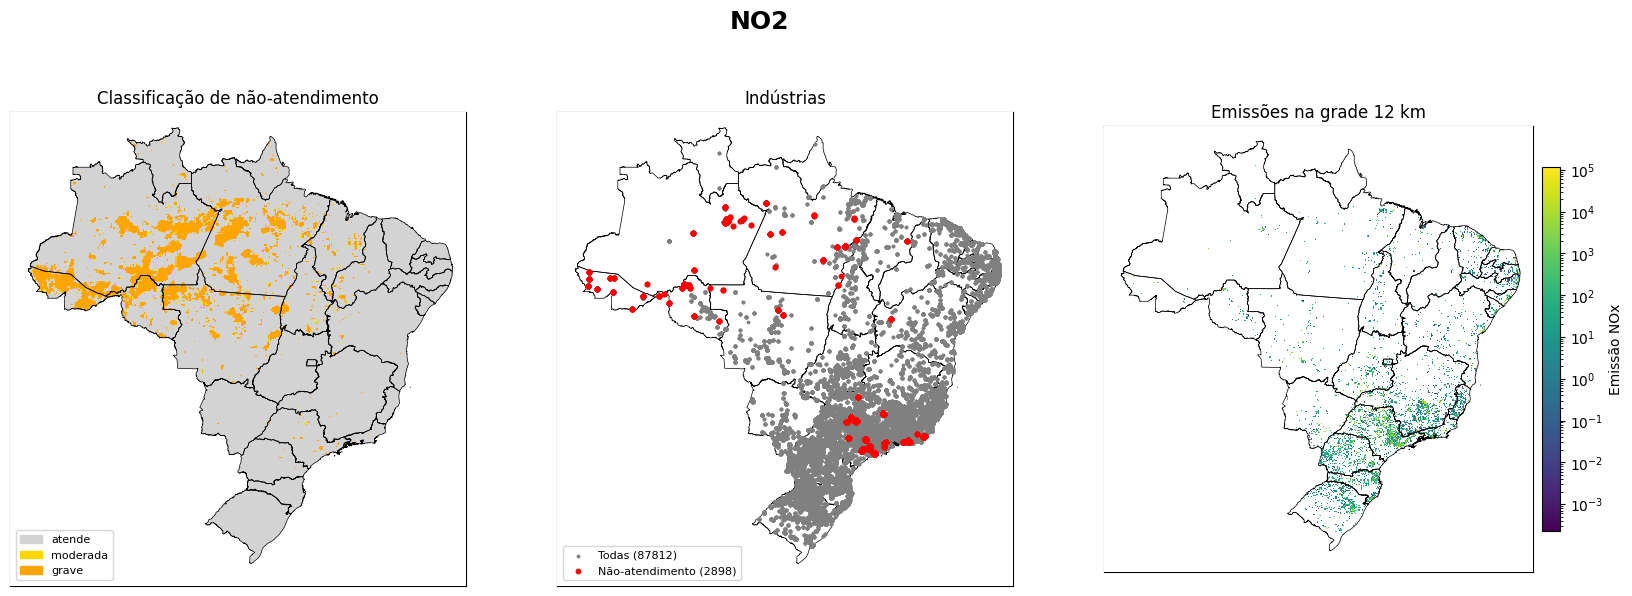

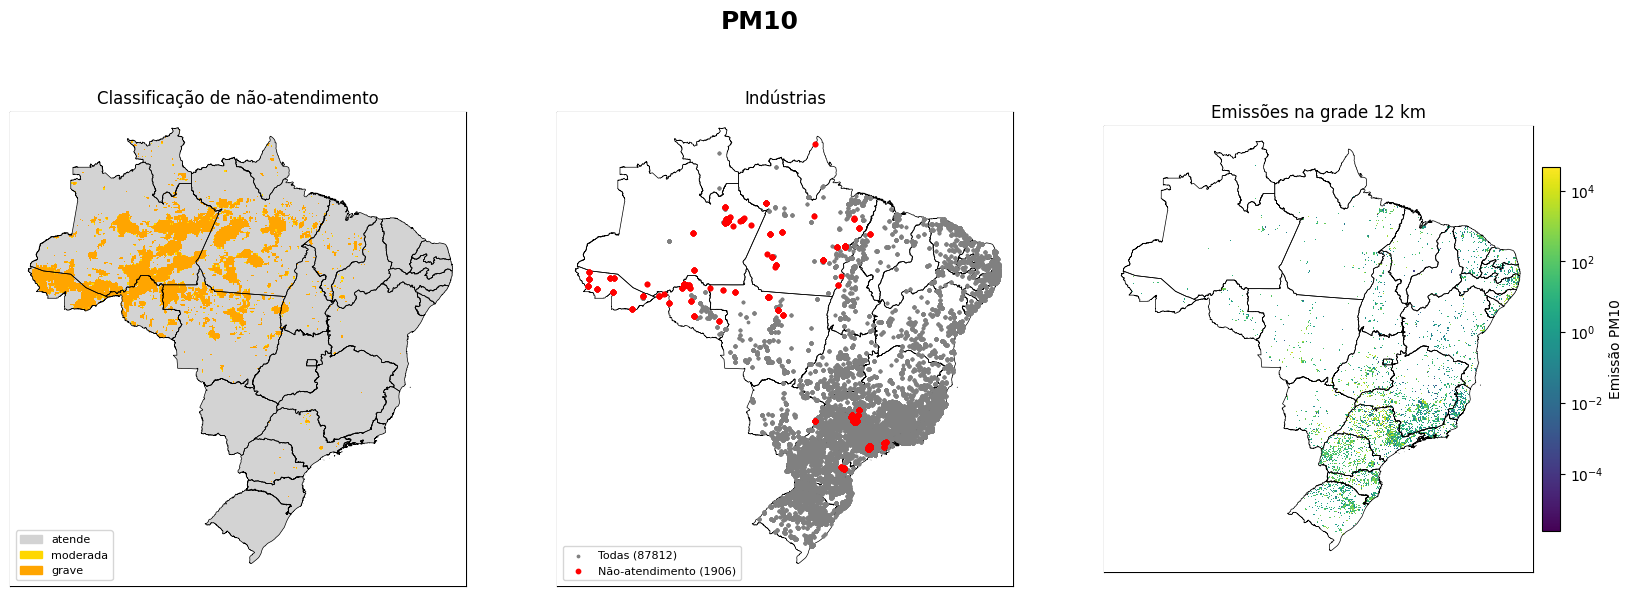

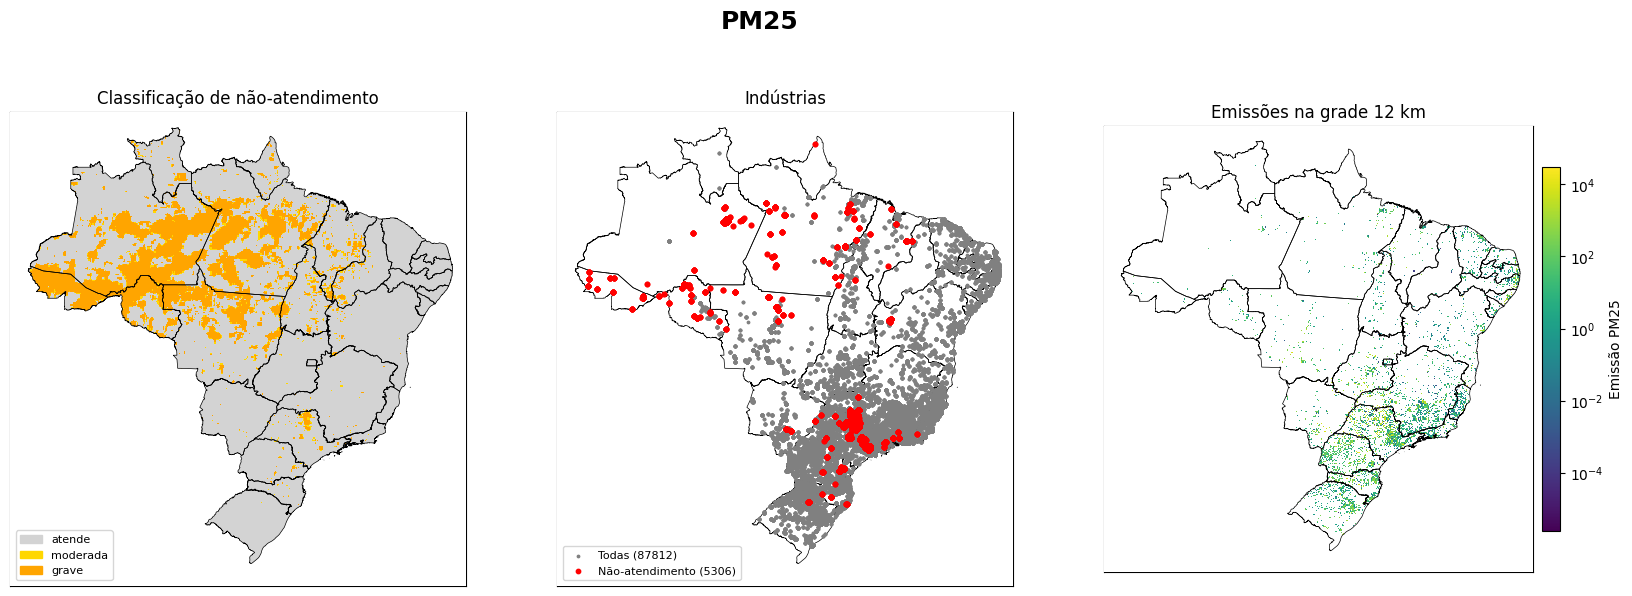

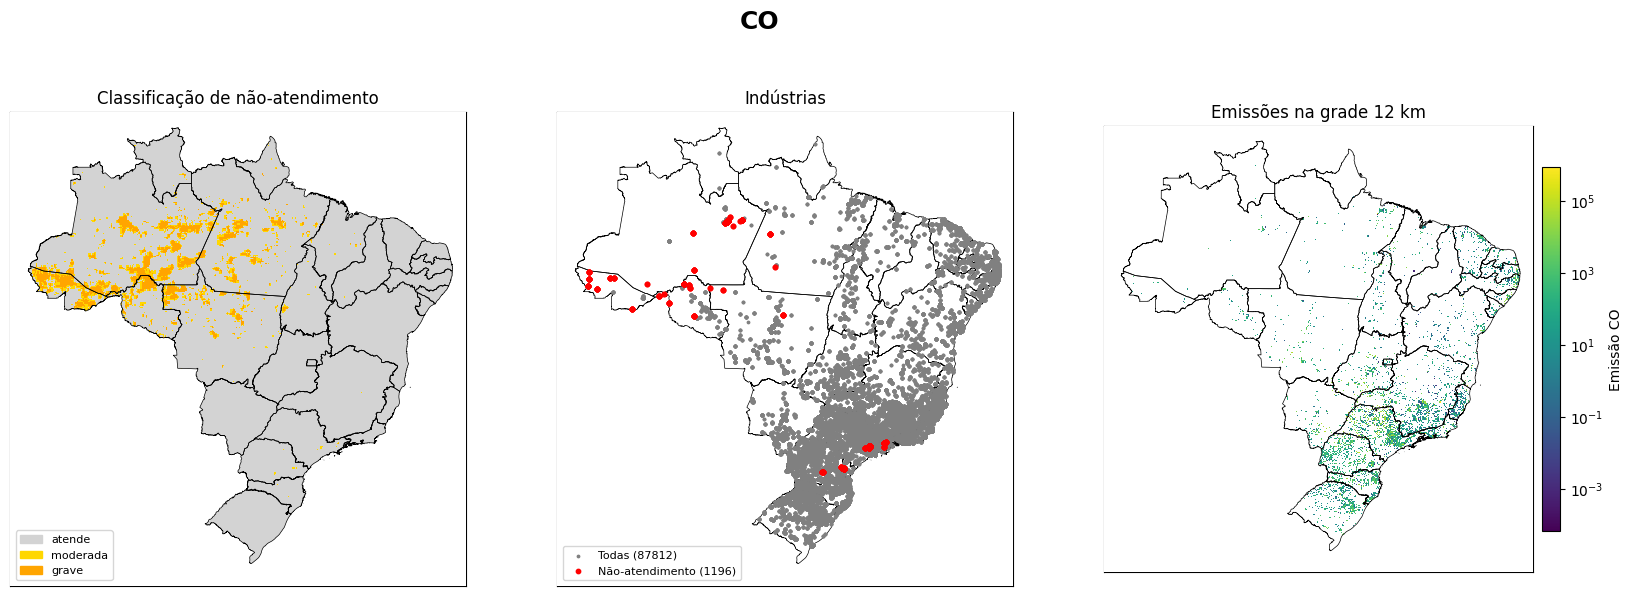

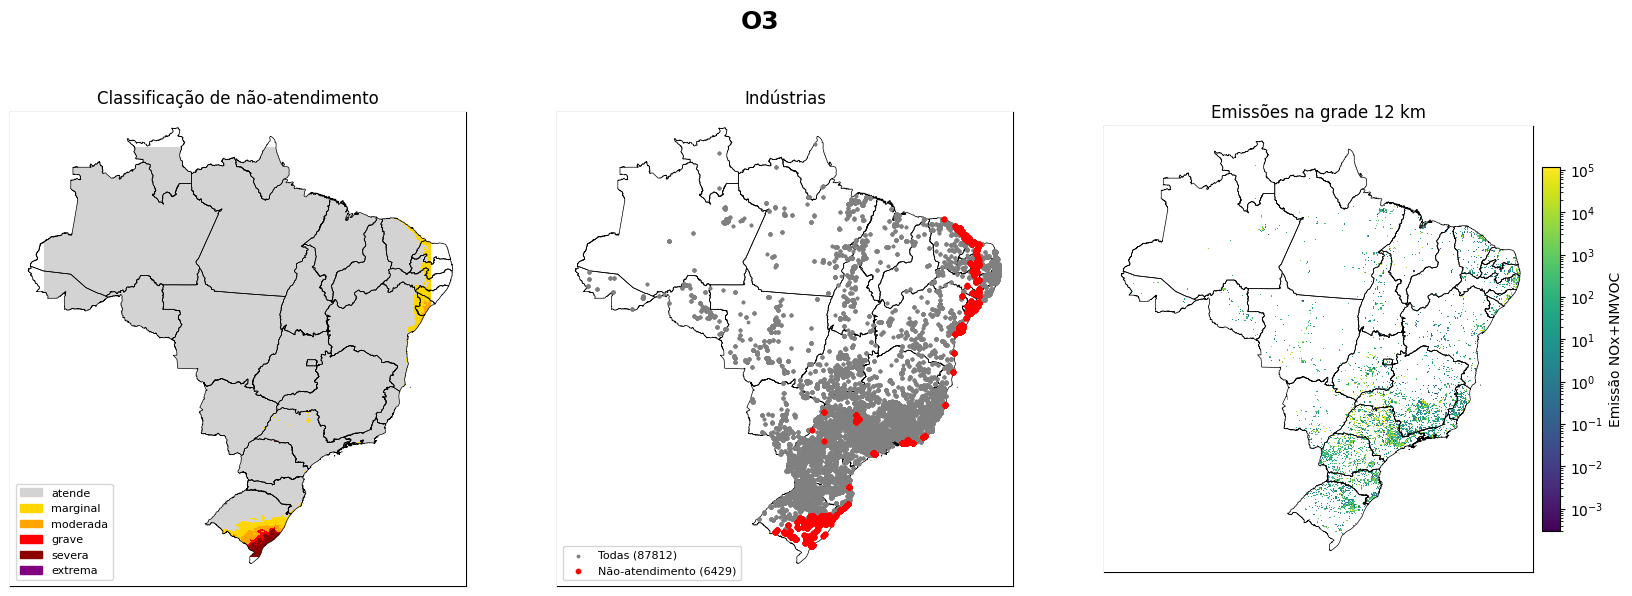

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LogNorm
from matplotlib.patches import Patch
import geopandas as gpd
from shapely.geometry import box

# ---- preparado UMA vez ----
brasil_4326 = brasil.to_crs('EPSG:4326')
uni = brasil_4326.union_all()
caixa = box(xlon.min()-1, ylat.min()-1, xlon.max()+1, ylat.max()+1)
fora_brasil = caixa.difference(uni)
rampa = ['lightgray', 'gold', 'orange', 'red', 'darkred', 'purple']

caminho_figuras = r'C:\Users\glima\OneDrive\Documentos\Mestrado_GitHub\007.2026 - AnaliseInvCMAQ\figures'
os.makedirs(caminho_figuras, exist_ok=True)

# qual emissão do inventário corresponde a cada poluente do CMAQ
emiss_de = {
    'NO2':  ['NOx'],
    'CO':   ['CO'],
    'PM10': ['PM10'],
    'PM25': ['PM25'],
    'O3':   ['NOx', 'NMVOC'],   # O3 é secundário: precursores
}

for pol in config:
    b = 0

    # ---------- mapa de classes + borda ----------
    classe_arr = resultados[pol]['classe'].values.astype(float).copy()
    if b > 0:
        classe_arr[:b, :] = np.nan; classe_arr[-b:, :] = np.nan
        classe_arr[:, :b] = np.nan; classe_arr[:, -b:] = np.nan

    # ---------- classe de cada indústria ----------
    classe_ind = np.full(len(inv_gdf_br), np.nan)
    classe_ind[dentro] = classe_arr[row[dentro], col[dentro]]
    todas = inv_gdf_br[dentro]
    viol  = inv_gdf_br[classe_ind >= 1]

    # ---------- emissões somadas na grade 12x12 (painel 3) ----------
    cols_e = emiss_de[pol]
    # soma as emissões das colunas relevantes, por indústria (texto -> número)
    val = inv_gdf_br[cols_e].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1).values
    emiss_grid = np.zeros((ds_ref.NROWS, ds_ref.NCOLS))
    np.add.at(emiss_grid, (row[dentro], col[dentro]), val[dentro])   # acumula por célula
    emiss_plot = np.where(emiss_grid > 0, emiss_grid, np.nan)        # zero -> branco

    # ---------- cores discretas das classes ----------
    nomes = config[pol]['classes']
    cores = rampa[:len(nomes)]
    cmap  = mcolors.ListedColormap(cores)
    norm  = mcolors.BoundaryNorm(np.arange(-0.5, len(nomes)+0.5), cmap.N)

    # ================= FIGURA 1x3 =================
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    # painel 1: classificação
    axes[0].pcolormesh(xlon, ylat, classe_arr, cmap=cmap, norm=norm, shading='auto')
    axes[0].legend(handles=[Patch(color=c, label=n) for c, n in zip(cores, nomes)],
                   loc='lower left', fontsize=8)
    axes[0].set_title('Classificação de não-atendimento')

    # painel 2: indústrias
    axes[1].scatter(todas['Longitude'], todas['Latitude'], s=3,  c='gray', zorder=7,
                    label=f'Todas ({len(todas)})')
    axes[1].scatter(viol['Longitude'],  viol['Latitude'],  s=10, c='red',  zorder=8,
                    label=f'Não-atendimento ({len(viol)})')
    axes[1].legend(loc='lower left', fontsize=8)
    axes[1].set_title('Indústrias')

    # painel 3: emissões na grade (escala log, pois varia ordens de grandeza)
    if np.isfinite(emiss_plot).any():
        m = axes[2].pcolormesh(xlon, ylat, emiss_plot, cmap='viridis',
                               norm=LogNorm(vmin=np.nanmin(emiss_plot), vmax=np.nanmax(emiss_plot)),
                               shading='auto')
        fig.colorbar(m, ax=axes[2], fraction=0.04, pad=0.02, label=f'Emissão {"+".join(cols_e)}')
    axes[2].set_title('Emissões na grade 12 km')

    # base do Brasil nos 3 painéis
    for ax in axes:
        gpd.GeoDataFrame(geometry=[fora_brasil], crs='EPSG:4326').plot(ax=ax, color='white', zorder=5)
        brasil_4326.boundary.plot(ax=ax, color='black', linewidth=0.5, zorder=6)
        ax.set_xlim(xlon.min(), xlon.max()); ax.set_ylim(ylat.min(), ylat.max())
        ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle(f'{pol}', fontsize=18, fontweight='bold')
    fig.savefig(os.path.join(caminho_figuras, f'mosaico_{pol}.png'), dpi=200, bbox_inches='tight')
    plt.show()

